In [3]:
!pip install geopy


  Using cached geopy-2.4.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached geographiclib-2.1-py3-none-any.whl.metadata (1.6 kB)
Using cached geopy-2.4.1-py3-none-any.whl (125 kB)
Using cached geographiclib-2.1-py3-none-any.whl (40 kB)

   -------------------- ------------------- 1/2 [geopy]
   ---------------------------------------- 2/2 [geopy]



In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb

import pickle
from geopy.geocoders import Nominatim
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)

In [3]:
# Load the dataset
df = pd.read_csv("C:/Projects/14_Emergency_RL_System/data/NYC.csv")
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [4]:
df.shape

(1458644, 11)

## Data Preprocessing

In [5]:
df['store_and_fwd_flag'].value_counts()

store_and_fwd_flag
N    1450599
Y       8045
Name: count, dtype: int64

In [6]:
# convert character variables to numeric
df["store_and_fwd_flag"] = df["store_and_fwd_flag"].replace({'N': 0, 'Y': 1})

C:\Users\shwey\AppData\Local\Temp\ipykernel_3372\2564580305.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["store_and_fwd_flag"] = df["store_and_fwd_flag"].replace({'N': 0, 'Y': 1})


In [7]:
# Check
df['store_and_fwd_flag'].value_counts()


store_and_fwd_flag
0    1450599
1       8045
Name: count, dtype: int64

## Feature engineering

In [8]:
# Convert datetime strings 
df["dropoff_datetime"] = pd.to_datetime(df["dropoff_datetime"], format='%Y-%m-%d %H:%M:%S')
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"], format='%Y-%m-%d %H:%M:%S')

In [9]:
# get the minute, hour, day , month
def extract_datetime_features(df, target_col):
    """
    Extracts temporal components from a datetime column.
    Ensures identical output to the original manual indexing.
    """
    df["pickup_month"] = df[target_col].dt.month
    df["pickup_day"] = df[target_col].dt.day
    df["pickup_weekday"] = df[target_col].dt.weekday
    df["pickup_hour"] = df[target_col].dt.hour
    df["pickup_minute"] = df[target_col].dt.minute
    return df

# Apply the function to dataframe
df = extract_datetime_features(df, "pickup_datetime")

In [10]:
# get the latitude and longitude difference
df["latitude_difference"] = df["dropoff_latitude"] - df["pickup_latitude"]
df["longitude_difference"] = df["dropoff_longitude"] - df["pickup_longitude"]

In [11]:
# Convert duration to minutes
df['trip_duration'] = df['trip_duration'].apply(lambda x: round(x/60) )

In [12]:
# Convert trip distance from longitude and latitude differences to Manhattan distancec
df["trip_distance"] = 0.621371 * 6371 * (abs(2 * np.arctan2(np.sqrt(np.square(np.sin((abs(df["latitude_difference"]) * np.pi / 180) / 2))), 
                                  np.sqrt(1-(np.square(np.sin((abs(df["latitude_difference"]) * np.pi / 180) / 2)))))) + \
                                     abs(2 * np.arctan2(np.sqrt(np.square(np.sin((abs(df["longitude_difference"]) * np.pi / 180) / 2))), 
                                  np.sqrt(1-(np.square(np.sin((abs(df["longitude_difference"]) * np.pi / 180) / 2)))))))

In [13]:
# Create a binary feature for rush hour
df['is_rush_hour'] = df['pickup_hour'].apply(lambda x: 1 if x in [7,8,9,17,18,19] else 0)

# create a binary feature for weekends
df["is_weekend"] = df['pickup_weekday'].apply(lambda x: 1 if x >=5 else 0)

In [14]:
# Remove the outliers
upper_limit = df['trip_duration'].quantile(0.99)
df = df[df['trip_duration'] < upper_limit]

In [15]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_month,pickup_day,pickup_weekday,pickup_hour,pickup_minute,latitude_difference,longitude_difference,trip_distance,is_rush_hour,is_weekend
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,0,8,3,14,0,17,24,-0.002335,0.017525,1.372146,1,0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,0,11,6,12,6,0,43,-0.007412,-0.019066,1.829440,0,1
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,0,35,1,19,1,11,35,-0.053852,-0.026306,5.538397,0,0
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,0,7,4,6,2,19,32,-0.013252,-0.002228,1.069567,1,0
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,0,7,3,26,5,13,30,-0.010689,0.000130,0.747485,0,1


## Modeling

In [16]:
from sklearn.metrics import mean_squared_error, r2_score

# Drop unnecessary columns for training
drop_cols = ['id','vendor_id', 'pickup_datetime', "dropoff_datetime", "trip_duration"]
X = df.drop(columns=drop_cols)
y = df['trip_duration']

# Split the data into training and test data set ( 80% train,  20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Transform the target to log scale
y_train_log = np.log1p(y_train)

# Initialize the XGBRegressor

model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

# Train the model
model.fit(X_train, y_train_log)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [18]:
# Predict on the test data
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Root Mean Squared Error: 3.90
R-squared Score: 0.83


<Axes: >

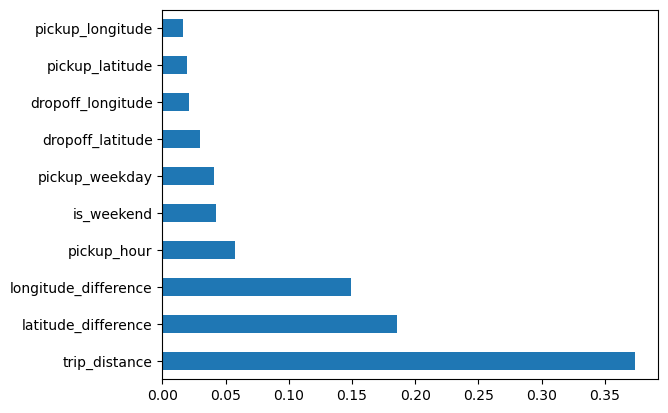

In [19]:
# Plot for the features the model values the most
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind="barh")

In [20]:
# Save the model
import joblib
joblib.dump(model, "model.pkl")
print("model saved successfully")

model saved successfully


In [21]:
import joblib

loaded_model = joblib.load("model.pkl")

print(type(loaded_model))

<class 'xgboost.sklearn.XGBRegressor'>
